<a href="https://colab.research.google.com/github/mohammedh897/chicago_crime_analysis/blob/main/chicago_crime_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Crime Analysis (2001–2022)
### Project 3 — Part 2 | SARIMA Forecasting for Resource Allocation
---
**Goal:** Forecast **Total Crime** and **Theft** for the next 6 months (Jan–Jun 2023) to support Chicago law enforcement resource allocation.  
**Method:** Manual SARIMA + pmdarima auto_arima, evaluated on a 6-month holdout, then retrained on the full dataset for true future forecasts.


## Step 0 — Install & Import Libraries

In [1]:
!pip install pmdarima gdown -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 4.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

import statsmodels.api as sm
import statsmodels.tsa.api as tsa
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)
import pmdarima as pm
import gdown, zipfile, os

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
print("Libraries loaded.")


Libraries loaded.


## Step 0b — Helper Functions
*(Source: ARIMA & SARIMA lessons)*

In [3]:
# ── 1. plot_forecast
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10, 4), title='Comparing Forecast vs. True Data'):
    fig, ax = plt.subplots(figsize=figsize)
    if n_train_lags is None:
        n_train_lags = len(ts_train)
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label='train')
    ts_test.plot(label='test', ax=ax)
    forecast_df['mean'].plot(ax=ax, color='green', label='forecast')
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                    forecast_df['mean_ci_upper'],
                    color='green', alpha=0.3, lw=2)
    ax.set_title(title)
    ax.legend()
    return fig, ax

# ── 2. get_adfuller_results
def get_adfuller_results(ts, alpha=0.05, label='adfuller', **kwargs):
    (test_stat, pval, nlags, nobs, crit_vals_d, icbest) = tsa.adfuller(ts, **kwargs)
    return pd.DataFrame({
        'Test Statistic':     test_stat,
        '# of Lags Used':    nlags,
        '# of Observations': nobs,
        'p-value':            round(pval, 6),
        'alpha':              alpha,
        'sig/stationary?':    pval < alpha
    }, index=[label])

# ── 3. regression_metrics_ts
def regression_metrics_ts(ts_true, ts_pred, label='', verbose=True, output_dict=False):
    mae       = mean_absolute_error(ts_true, ts_pred)
    mse       = mean_squared_error(ts_true, ts_pred)
    rmse      = np.sqrt(mse)
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc  = mean_absolute_percentage_error(ts_true, ts_pred) * 100
    if verbose:
        header = '---' * 20
        print(header, f'Regression Metrics: {label}', header, sep='\n')
        print(f'- MAE  = {mae:,.3f}')
        print(f'- MSE  = {mse:,.3f}')
        print(f'- RMSE = {rmse:,.3f}')
        print(f'- R^2  = {r_squared:,.3f}')
        print(f'- MAPE = {mae_perc:,.2f}%')
    if output_dict:
        return {'Label': label, 'MAE': mae, 'MSE': mse,
                'RMSE': rmse, 'R^2': r_squared, 'MAPE(%)': mae_perc}

# ── 4. get_sig_lags
def get_sig_lags(ts, type='ACF', nlags=None, alpha=0.05):
    if type == 'ACF':
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)
    elif type == 'PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)
    else:
        raise Exception("type must be 'ACF' or 'PACF'")
    lags = range(len(corr_values))
    corr_df = pd.DataFrame({
        type:       corr_values,
        'Lags':     lags,
        'lower ci': conf_int[:, 0] - corr_values,
        'upper ci': conf_int[:, 1] - corr_values,
    }).set_index('Lags')
    filter_sig = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])
    sig_lags = corr_df.index[filter_sig]
    return sig_lags[sig_lags != 0]

# ── 5. plot_acf_pacf
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=0.05,
                  acf_kws={}, pacf_kws={},
                  annotate_seas=False, m=None, seas_color='black'):
    fig, axes = plt.subplots(nrows=2, figsize=figsize)
    sig_vline_kwargs = dict(ls=':', lw=1, zorder=0, color='red')
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)
    if annotate_sig:
        for lag in get_sig_lags(ts, nlags=nlags, alpha=alpha, type='ACF'):
            axes[0].axvline(lag, label='sig', **sig_vline_kwargs)
    tsa.graphics.plot_pacf(ts, ax=axes[1], lags=nlags, **pacf_kws)
    if annotate_sig:
        for lag in get_sig_lags(ts, nlags=nlags, alpha=alpha, type='PACF'):
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)
    if annotate_seas:
        if m is None:
            raise Exception('Must define m if annotate_seas=True.')
        seas_vline_kwargs = dict(ls='--', lw=1, alpha=0.7, color=seas_color, zorder=-1)
        for i in range(1, nlags // m + 1):
            axes[0].axvline(m * i, **seas_vline_kwargs, label='season')
            axes[1].axvline(m * i, **seas_vline_kwargs, label='season')
    fig.tight_layout()
    return fig

# ── 6. get_forecast_df
def get_forecast_df(forecast_result):
    ci = forecast_result.conf_int()
    return pd.DataFrame({
        'mean':           forecast_result.predicted_mean,
        'mean_ci_lower':  ci.iloc[:, 0],
        'mean_ci_upper':  ci.iloc[:, 1],
    })

print("Helper functions defined.")


Helper functions defined.


## Step 1 — Load Data

In [4]:
GDRIVE_LINK = "https://drive.google.com/uc?id=1avxUlCAros-R9GF6SKXqM_GopzO7VwA5"
gdown.download(GDRIVE_LINK, "chicago_crimes.zip", quiet=False, fuzzy=True)

with zipfile.ZipFile("chicago_crimes.zip", "r") as z:
    csv_names = sorted([n for n in z.namelist() if n.endswith(".csv")])
    chunks = []
    for name in csv_names:
        with z.open(name) as f:
            chunks.append(pd.read_csv(f, low_memory=False))

df_raw = pd.concat(chunks, ignore_index=True)
print(f"Rows loaded: {len(df_raw):,}")


Downloading...
From (original): https://drive.google.com/uc?id=1avxUlCAros-R9GF6SKXqM_GopzO7VwA5
From (redirected): https://drive.google.com/uc?id=1avxUlCAros-R9GF6SKXqM_GopzO7VwA5&confirm=t&uuid=44ab0fd9-8597-4704-bd09-5aa7f9dbffba
To: /content/chicago_crimes.zip
100%|██████████| 196M/196M [00:02<00:00, 75.2MB/s]


Rows loaded: 7,713,109


## Step 2 — Clean & Prepare

In [5]:
df = df_raw.copy()
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df = df.dropna(subset=['Date']).set_index('Date').sort_index()
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Shape: {df.shape}")


Date range: 2001-01-01 00:00:00 to 2022-12-31 23:55:00
Shape: (7713109, 11)


## Step 3 — Build Monthly Time Series

Total Crime — months: 264, nulls: 0
Theft       — months: 264, nulls: 0


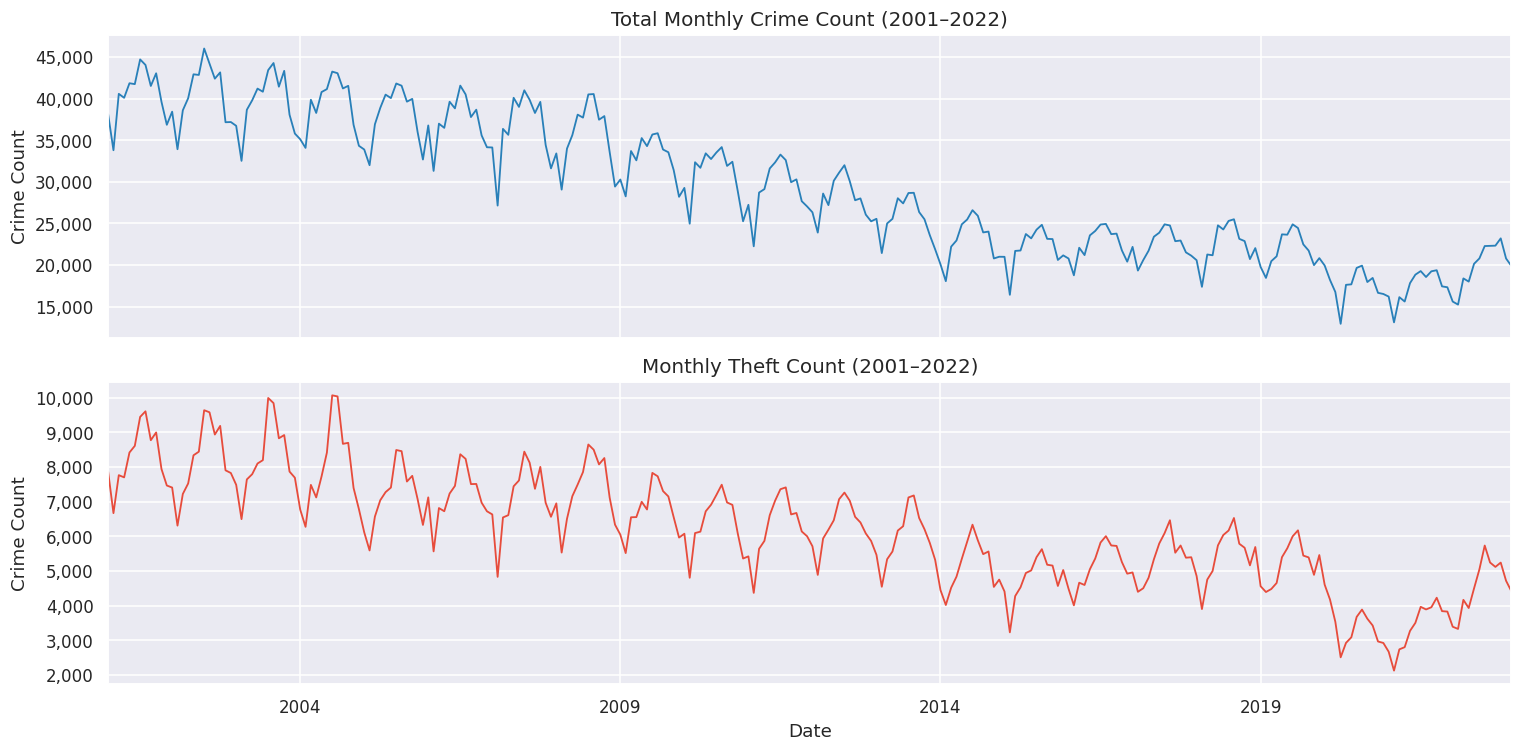

In [6]:
total_monthly = df.resample('MS').size().rename('Crime_Count')
theft_monthly = df[df['Primary Type'] == 'THEFT'].resample('MS').size().rename('Crime_Count')

# Check for null values
print(f"Total Crime — months: {len(total_monthly)}, nulls: {total_monthly.isna().sum()}")
print(f"Theft       — months: {len(theft_monthly)}, nulls: {theft_monthly.isna().sum()}")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
total_monthly.plot(ax=axes[0], color='#2980b9', linewidth=1.2)
axes[0].set_title("Total Monthly Crime Count (2001–2022)")
axes[0].set_ylabel("Crime Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))

theft_monthly.plot(ax=axes[1], color='#e74c3c', linewidth=1.2)
axes[1].set_title("Monthly Theft Count (2001–2022)")
axes[1].set_ylabel("Crime Count")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
plt.tight_layout()
plt.show()


---
# Part A — Total Crime Forecasting

### A1 — Seasonal Decomposition

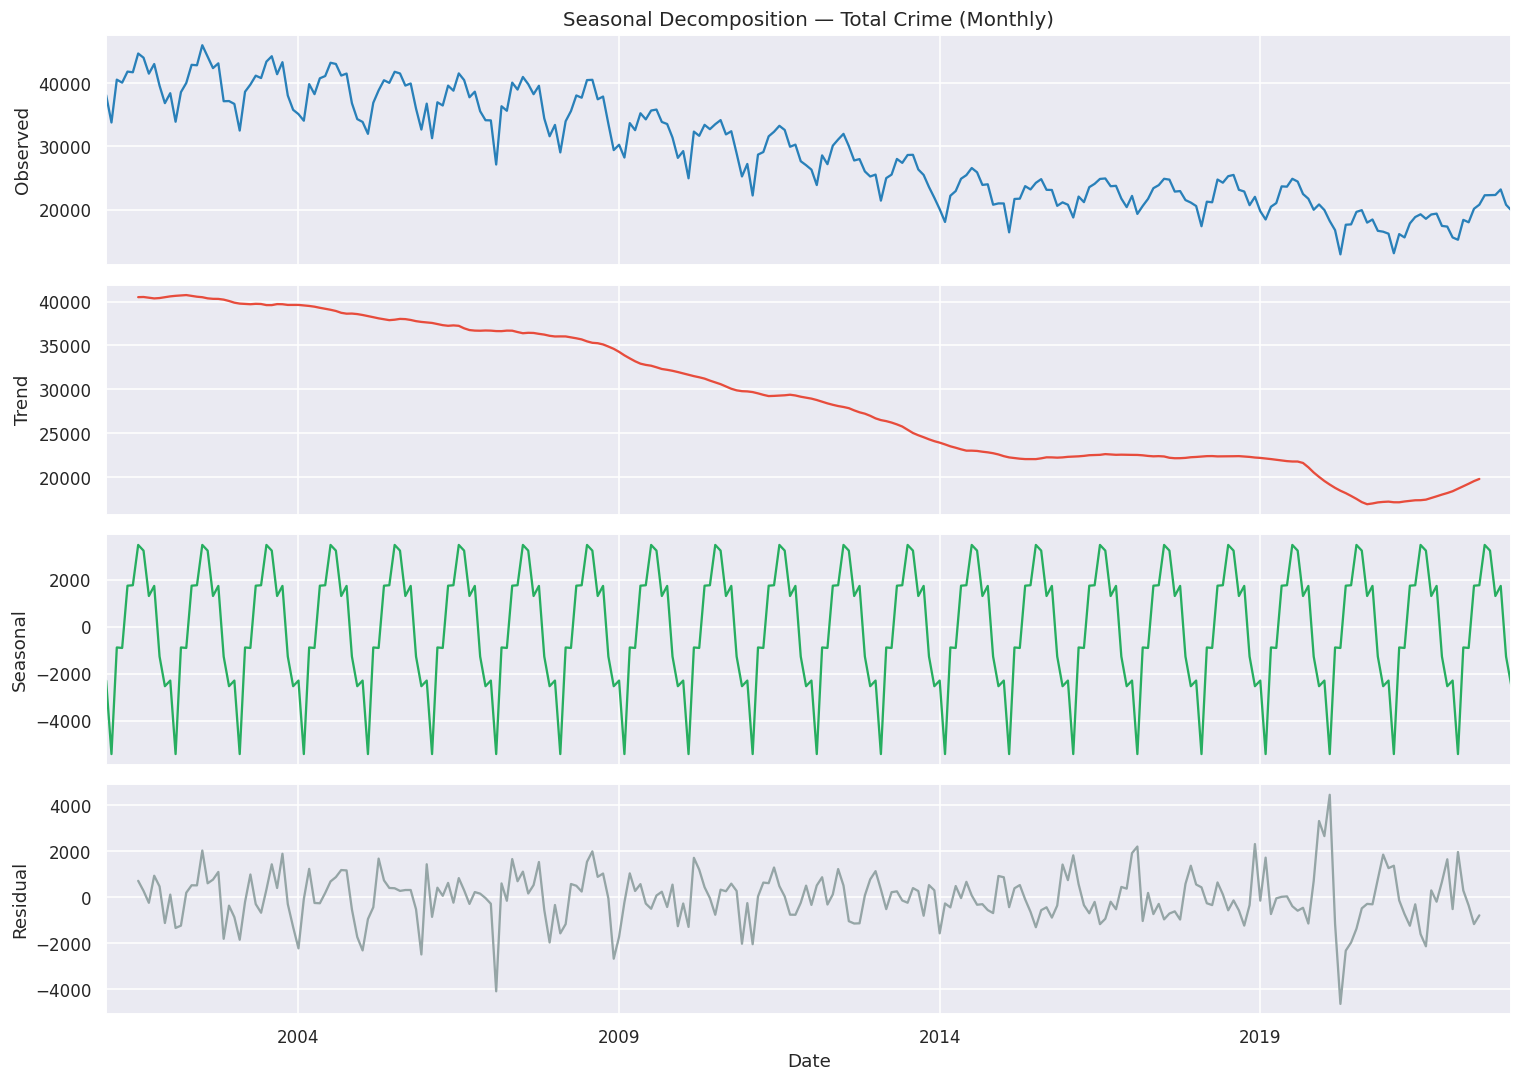

Seasonal magnitude: 8,898 crimes/month
Conclusion: Strong annual seasonality detected -> use SARIMA with s=12


In [7]:
decomp_total = seasonal_decompose(total_monthly, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp_total.observed.plot(ax=axes[0], color='#2980b9');  axes[0].set_ylabel('Observed')
decomp_total.trend.plot(ax=axes[1], color='#e74c3c');     axes[1].set_ylabel('Trend')
decomp_total.seasonal.plot(ax=axes[2], color='#27ae60');  axes[2].set_ylabel('Seasonal')
decomp_total.resid.plot(ax=axes[3], color='#95a5a6');     axes[3].set_ylabel('Residual')
axes[0].set_title("Seasonal Decomposition — Total Crime (Monthly)")
plt.tight_layout()
plt.show()

seasonal_range = decomp_total.seasonal.max() - decomp_total.seasonal.min()
print(f"Seasonal magnitude: {seasonal_range:,.0f} crimes/month")
print("Conclusion: Strong annual seasonality detected -> use SARIMA with s=12")


### A2 — Stationarity Tests (ADF)

In [8]:
print("=== Total Crime — ADF Results ===\n")

adf_raw = get_adfuller_results(total_monthly, label='Raw')
adf_d1  = get_adfuller_results(total_monthly.diff().dropna(), label='d=1')
adf_D1  = get_adfuller_results(total_monthly.diff(12).dropna(), label='D=1 (s=12)')
adf_d1D1= get_adfuller_results(total_monthly.diff().diff(12).dropna(), label='d=1, D=1')

adf_summary = pd.concat([adf_raw, adf_d1, adf_D1, adf_d1D1])
display(adf_summary)

print("\nConclusion: d=1 achieves stationarity. D=1 applied to remove annual seasonal pattern.")
print("Final differencing: d=1, D=1, s=12")


=== Total Crime — ADF Results ===



,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
Raw,-1.325784,15,248,0.617295,0.05,False
d=1,-3.040410,14,248,0.031289,0.05,True
D=1 (s=12),-2.741936,12,239,0.067058,0.05,False
"d=1, D=1",-5.216604,14,236,0.000008,0.05,True



Conclusion: d=1 achieves stationarity. D=1 applied to remove annual seasonal pattern.
Final differencing: d=1, D=1, s=12


### A3 — ACF & PACF on Differenced Series

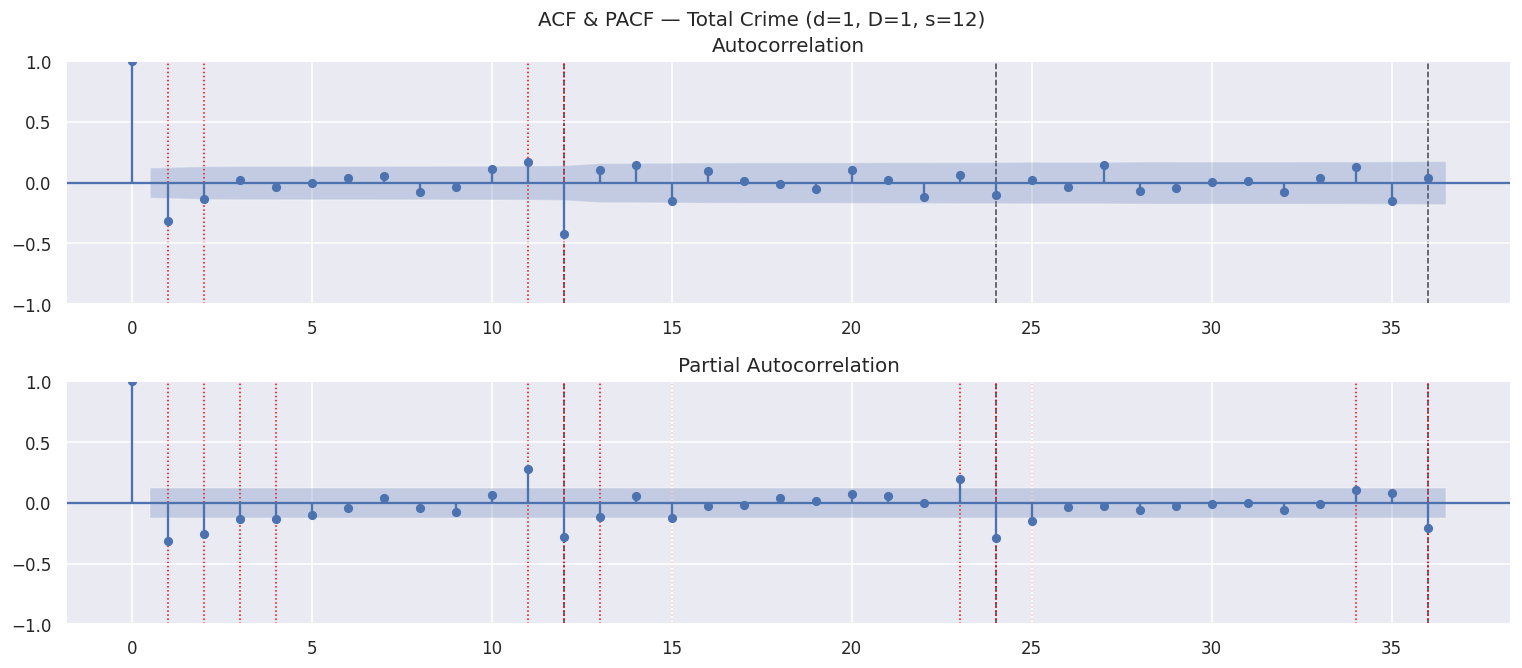

ACF:  significant spike at lag 1  -> MA(1) term
PACF: significant spike at lag 1  -> AR(1) term
Seasonal spikes at lag 12 in both -> P=1, Q=1

Selected manual order: SARIMA(1,1,1)(1,1,1,12)


In [9]:
diff_total = total_monthly.diff().diff(12).dropna()

fig = plot_acf_pacf(diff_total, nlags=36, figsize=(14, 6),
                    annotate_sig=True, annotate_seas=True, m=12)
fig.suptitle("ACF & PACF — Total Crime (d=1, D=1, s=12)", y=1.01, fontsize=13)
plt.show()

print("ACF:  significant spike at lag 1  -> MA(1) term")
print("PACF: significant spike at lag 1  -> AR(1) term")
print("Seasonal spikes at lag 12 in both -> P=1, Q=1")
print("\nSelected manual order: SARIMA(1,1,1)(1,1,1,12)")


### A4 — Train / Test Split (6-month holdout)

In [10]:
train_total = total_monthly.iloc[:-6]
test_total  = total_monthly.iloc[-6:]

print(f"Train: {train_total.index[0].date()} to {train_total.index[-1].date()}  ({len(train_total)} months)")
print(f"Test:  {test_total.index[0].date()}  to {test_total.index[-1].date()}   ({len(test_total)} months)")
print(f"\nTest period (actual values):")
print(test_total.to_string())


Train: 2001-01-01 to 2022-06-01  (258 months)
Test:  2022-07-01  to 2022-12-01   (6 months)

Test period (actual values):
Date
2022-07-01    22271
2022-08-01    22293
2022-09-01    22318
2022-10-01    23195
2022-11-01    20776
2022-12-01    19875
Freq: MS


### A5 — Manual SARIMA(1,1,1)(1,1,1,12)

In [11]:
model_total_manual = SARIMAX(train_total,
                              order=(1, 1, 1),
                              seasonal_order=(1, 1, 1, 12)).fit(disp=False)
print(model_total_manual.summary())


                                     SARIMAX Results                                      
Dep. Variable:                        Crime_Count   No. Observations:                  258
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2105.415
Date:                            Mon, 20 Jul 2026   AIC                           4220.829
Time:                                    20:16:40   BIC                           4238.336
Sample:                                01-01-2001   HQIC                          4227.879
                                     - 06-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4174      0.195      2.139      0.032       0.035       0.800
ma.L1         -0.5757      0.186   

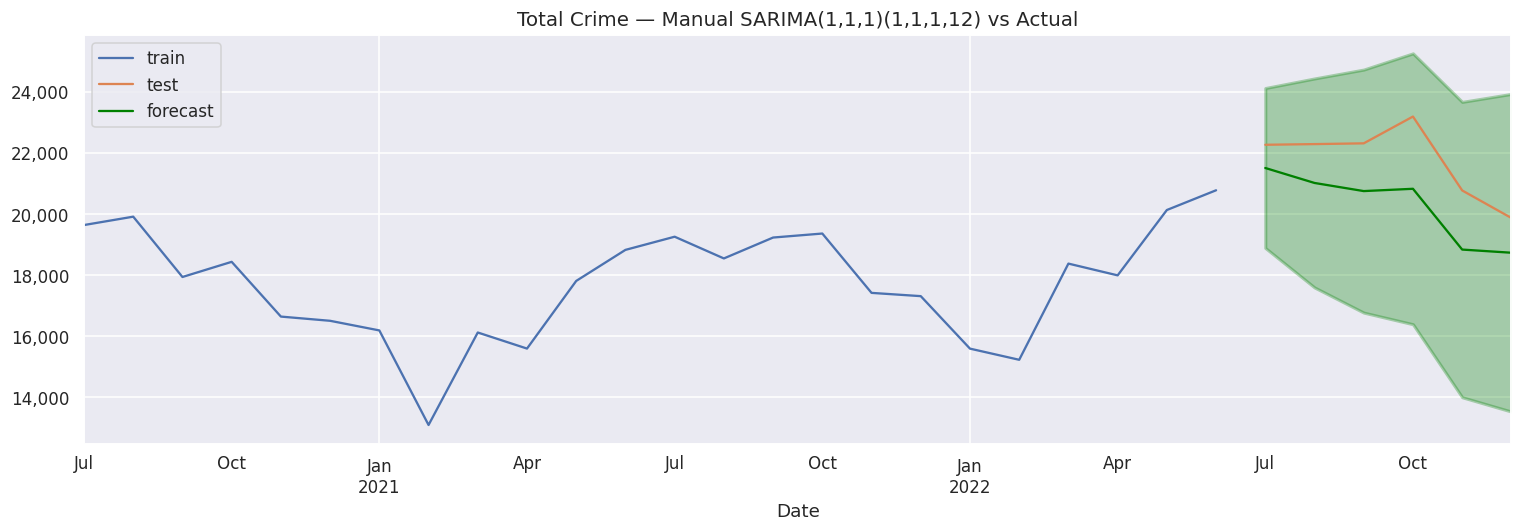

------------------------------------------------------------
Regression Metrics: Total Crime — Manual SARIMA(1,1,1)(1,1,1,12)
------------------------------------------------------------
- MAE  = 1,505.131
- MSE  = 2,544,007.190
- RMSE = 1,594.994
- R^2  = -1.054
- MAPE = 6.89%


In [12]:
# Forecast and build forecast_df using helper
result_total_manual = model_total_manual.get_forecast(6)
forecast_df_total_manual = get_forecast_df(result_total_manual)
forecast_df_total_manual.index = test_total.index

# Plot using plot_forecast helper
fig, ax = plot_forecast(train_total, test_total, forecast_df_total_manual,
                        n_train_lags=24,
                        figsize=(14, 5),
                        title="Total Crime — Manual SARIMA(1,1,1)(1,1,1,12) vs Actual")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
plt.tight_layout()
plt.show()

# Metrics using helper
regression_metrics_ts(test_total, forecast_df_total_manual['mean'],
                      label='Total Crime — Manual SARIMA(1,1,1)(1,1,1,12)')


### A6 — auto_arima Tuning

In [13]:
aa_total = pm.auto_arima(train_total,
                          seasonal=True, m=12,
                          d=1, D=1,
                          stepwise=True,
                          suppress_warnings=True,
                          error_action='ignore',
                          trace=True)
print(f"\nBest order:    {aa_total.order}")
print(f"Seasonal order: {aa_total.seasonal_order}")


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=4224.032, Time=1.55 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=4269.891, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=4245.663, Time=0.23 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=4234.448, Time=0.30 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=4237.292, Time=1.11 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=4246.924, Time=1.34 sec
 ARIMA(2,1,2)(2,1,1)[12]             : AIC=4219.597, Time=8.77 sec
 ARIMA(2,1,2)(2,1,0)[12]             : AIC=4232.361, Time=2.68 sec
 ARIMA(2,1,2)(2,1,2)[12]             : AIC=4222.805, Time=8.21 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=4222.771, Time=5.75 sec
 ARIMA(1,1,2)(2,1,1)[12]             : AIC=4220.118, Time=2.21 sec
 ARIMA(2,1,1)(2,1,1)[12]             : AIC=4217.952, Time=7.05 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=4222.587, Time=1.03 sec
 ARIMA(2,1,1)(2,1,0)[12]             : AIC=4230.773, Time=1.62 sec
 ARIMA(2,1,1)(2,1,2

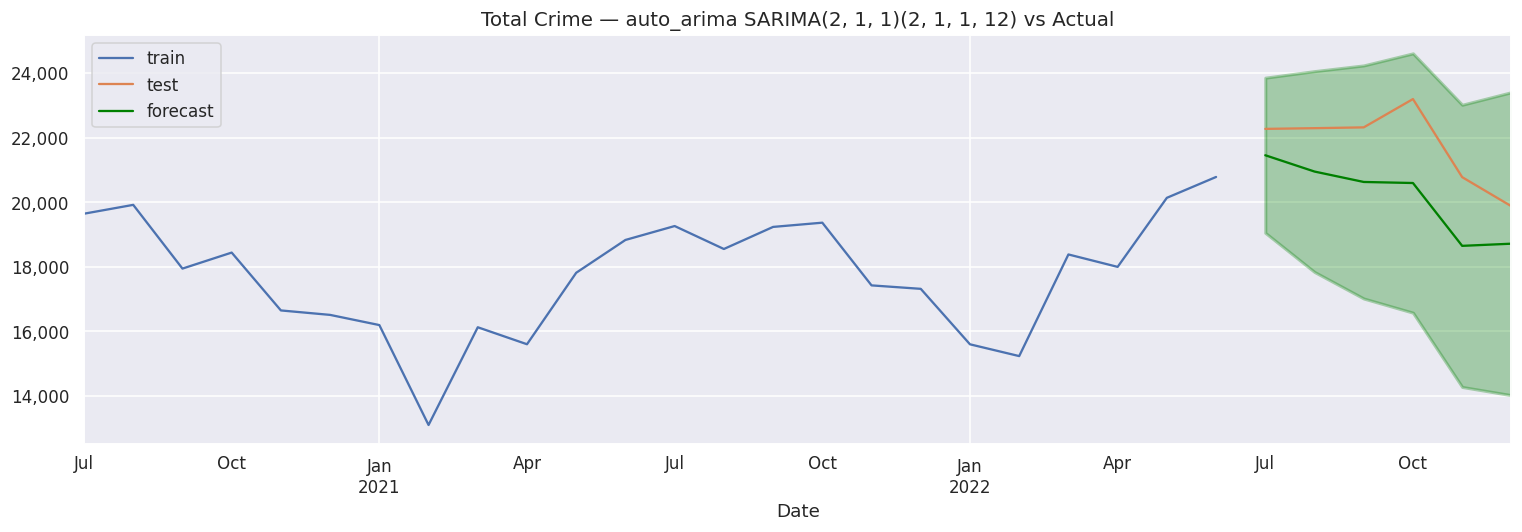

------------------------------------------------------------
Regression Metrics: Total Crime — auto_arima SARIMA(2, 1, 1)(2, 1, 1, 12)
------------------------------------------------------------
- MAE  = 1,623.099
- MSE  = 2,994,064.006
- RMSE = 1,730.336
- R^2  = -1.417
- MAPE = 7.43%


In [14]:
# Refit best auto_arima params using SARIMAX to get get_forecast() support
p, d, q = aa_total.order
P, D, Q, m = aa_total.seasonal_order

model_total_auto = SARIMAX(train_total,
                            order=(p, d, q),
                            seasonal_order=(P, D, Q, m)).fit(disp=False)

result_total_auto = model_total_auto.get_forecast(6)
forecast_df_total_auto = get_forecast_df(result_total_auto)
forecast_df_total_auto.index = test_total.index

fig, ax = plot_forecast(train_total, test_total, forecast_df_total_auto,
                        n_train_lags=24,
                        figsize=(14, 5),
                        title=f"Total Crime — auto_arima SARIMA{aa_total.order}{aa_total.seasonal_order} vs Actual")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
plt.tight_layout()
plt.show()

regression_metrics_ts(test_total, forecast_df_total_auto['mean'],
                      label=f'Total Crime — auto_arima SARIMA{aa_total.order}{aa_total.seasonal_order}')


### A7 — Model Selection

| Model | MAE | RMSE | MAPE |
|---|---|---|---|
| Manual SARIMA(1,1,1)(1,1,1,12) | 1,505 | 1,595 | 6.89% |
| auto_arima (2,1,1)(2,1,1,12) | 1,623 | 1,730 | 7.43% |

**Selected: Manual SARIMA(1,1,1)(1,1,1,12)**

The manual model outperforms auto_arima on all three metrics (MAE, RMSE, MAPE). The auto_arima model selects a more complex order with AR(2) and SAR(2) terms that add complexity without improving test accuracy. The manual SARIMA is more parsimonious and generalizes better to the 6-month holdout.


### A8 — True Future Forecast (Jan–Jun 2023)

Total Crime — True Future Forecast (Jan–Jun 2023):
2023-01-01    18731.0
2023-02-01    17571.0
2023-03-01    20482.0
2023-04-01    19991.0
2023-05-01    22394.0
2023-06-01    22893.0
Freq: MS


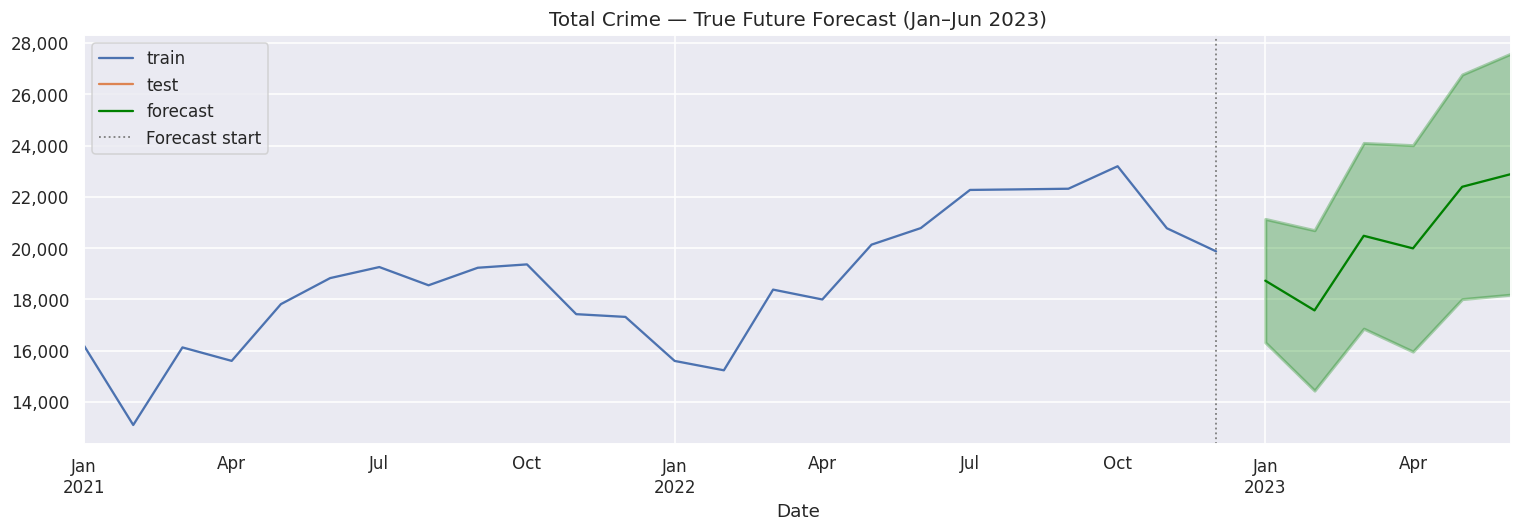

In [15]:
# Retrain selected model on full dataset
final_model_total = SARIMAX(total_monthly,
                              order=(1, 1, 1),
                              seasonal_order=(1, 1, 1, 12)).fit(disp=False)

future_idx = pd.date_range(start='2023-01-01', periods=6, freq='MS')
result_future_total = final_model_total.get_forecast(6)
forecast_df_future_total = get_forecast_df(result_future_total)
forecast_df_future_total.index = future_idx

print("Total Crime — True Future Forecast (Jan–Jun 2023):")
print(forecast_df_future_total['mean'].round(0).to_string())

# Dummy test series for plot_forecast (future — no actuals)
dummy_test = pd.Series(dtype=float, index=future_idx, name='Crime_Count')

fig, ax = plot_forecast(total_monthly, dummy_test, forecast_df_future_total,
                        n_train_lags=24, figsize=(14, 5),
                        title="Total Crime — True Future Forecast (Jan–Jun 2023)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
ax.axvline(total_monthly.index[-1], color='gray', linestyle=':', linewidth=1.2, label='Forecast start')
ax.legend()
plt.tight_layout()
plt.show()


### A9 — Net Change & Percent Change

In [16]:
fc_total = forecast_df_future_total['mean']
delta_total = fc_total.iloc[-1] - fc_total.iloc[0]
pct_total   = delta_total / fc_total.iloc[0] * 100

print(f"Forecast start (Jan 2023): {fc_total.iloc[0]:,.0f} crimes")
print(f"Forecast end   (Jun 2023): {fc_total.iloc[-1]:,.0f} crimes")
print(f"Net change:    {delta_total:+,.0f} crimes")
print(f"Percent change: {pct_total:+.2f}%")


Forecast start (Jan 2023): 18,731 crimes
Forecast end   (Jun 2023): 22,893 crimes
Net change:    +4,162 crimes
Percent change: +22.22%


**Total Crime Forecast Analysis**

- **Net change:** +4,162 crimes from January to June 2023
- **Percent change:** +22.22%

The forecast reflects the strong annual summer surge consistently observed across 22 years of historical data. Total crime is expected to rise steadily from a January trough through a June peak, driven by the seasonal component identified in the decomposition.


---
# Part B — Theft Forecasting

### B1 — Seasonal Decomposition

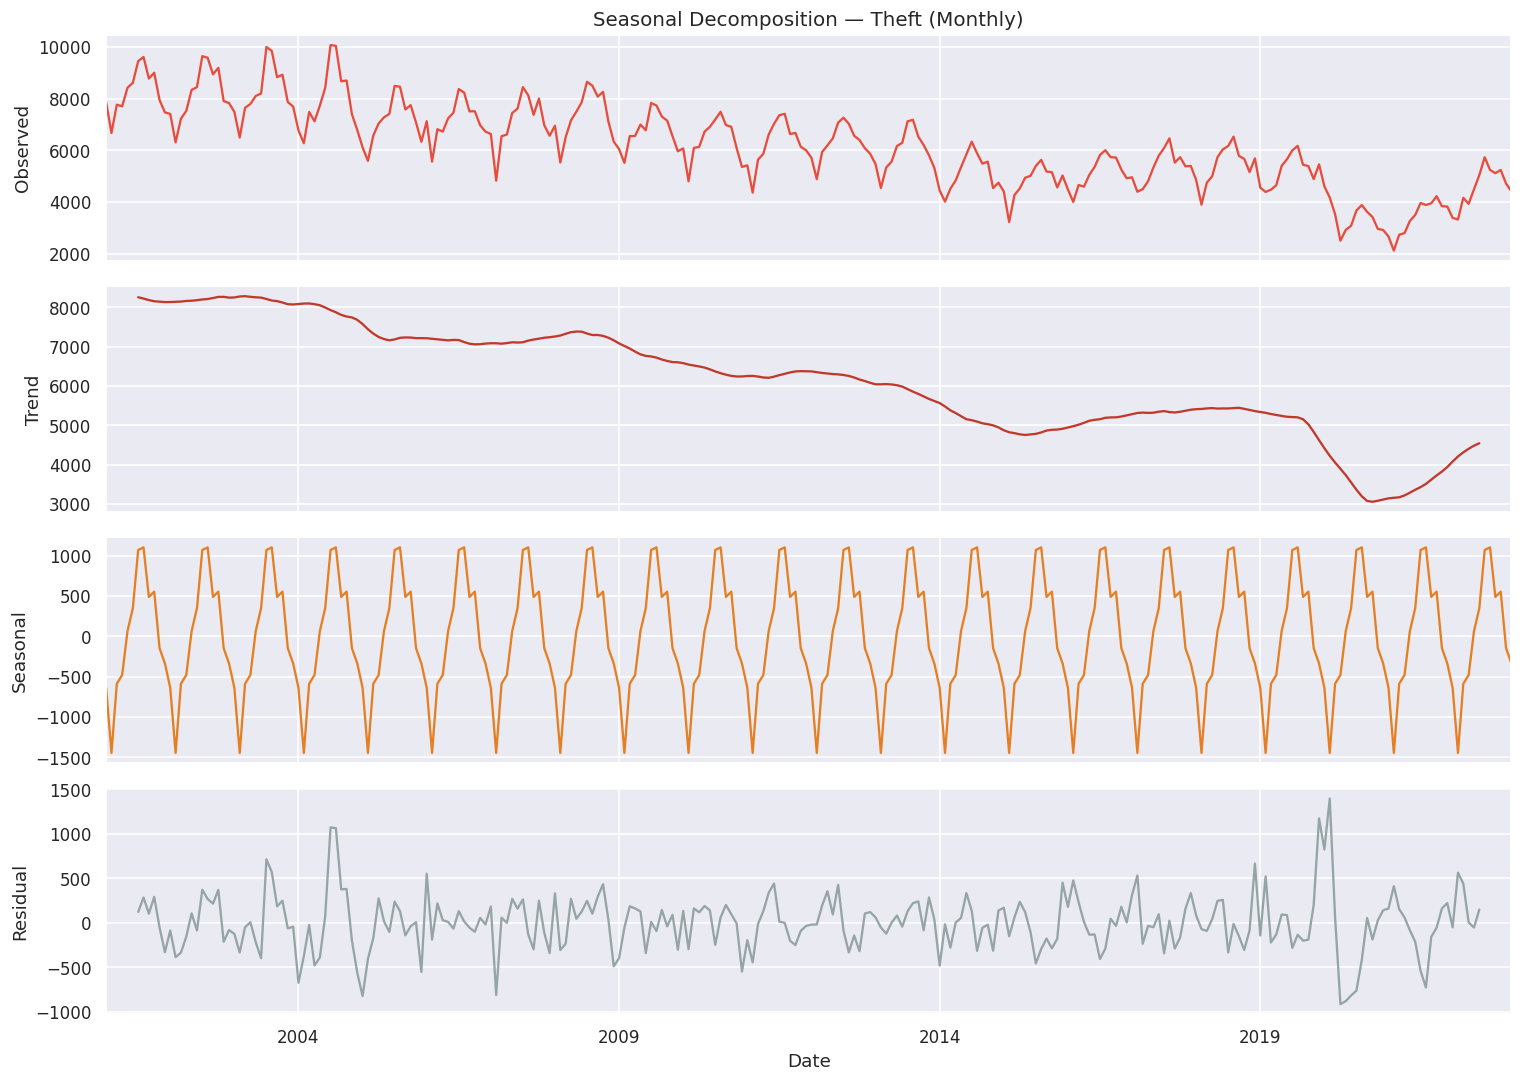

Seasonal magnitude: 2,550 thefts/month
Conclusion: Clear annual seasonality -> use SARIMA with s=12


In [17]:
decomp_theft = seasonal_decompose(theft_monthly, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp_theft.observed.plot(ax=axes[0], color='#e74c3c');  axes[0].set_ylabel('Observed')
decomp_theft.trend.plot(ax=axes[1], color='#c0392b');     axes[1].set_ylabel('Trend')
decomp_theft.seasonal.plot(ax=axes[2], color='#e67e22');  axes[2].set_ylabel('Seasonal')
decomp_theft.resid.plot(ax=axes[3], color='#95a5a6');     axes[3].set_ylabel('Residual')
axes[0].set_title("Seasonal Decomposition — Theft (Monthly)")
plt.tight_layout()
plt.show()

seasonal_range_theft = decomp_theft.seasonal.max() - decomp_theft.seasonal.min()
print(f"Seasonal magnitude: {seasonal_range_theft:,.0f} thefts/month")
print("Conclusion: Clear annual seasonality -> use SARIMA with s=12")


### B2 — Stationarity Tests (ADF)

In [18]:
print("=== Theft — ADF Results ===\n")

adf_raw_th  = get_adfuller_results(theft_monthly, label='Raw')
adf_d1_th   = get_adfuller_results(theft_monthly.diff().dropna(), label='d=1')
adf_D1_th   = get_adfuller_results(theft_monthly.diff(12).dropna(), label='D=1 (s=12)')
adf_d1D1_th = get_adfuller_results(theft_monthly.diff().diff(12).dropna(), label='d=1, D=1')

adf_summary_th = pd.concat([adf_raw_th, adf_d1_th, adf_D1_th, adf_d1D1_th])
display(adf_summary_th)

print("\nConclusion: d=1 achieves stationarity. D=1 applied for seasonal pattern.")
print("Final differencing: d=1, D=1, s=12")


=== Theft — ADF Results ===



,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
Raw,-1.393935,13,250,0.585180,0.05,False
d=1,-3.953728,12,250,0.001673,0.05,True
D=1 (s=12),-3.935542,14,237,0.001788,0.05,True
"d=1, D=1",-5.482433,12,238,0.000002,0.05,True



Conclusion: d=1 achieves stationarity. D=1 applied for seasonal pattern.
Final differencing: d=1, D=1, s=12


### B3 — ACF & PACF on Differenced Series

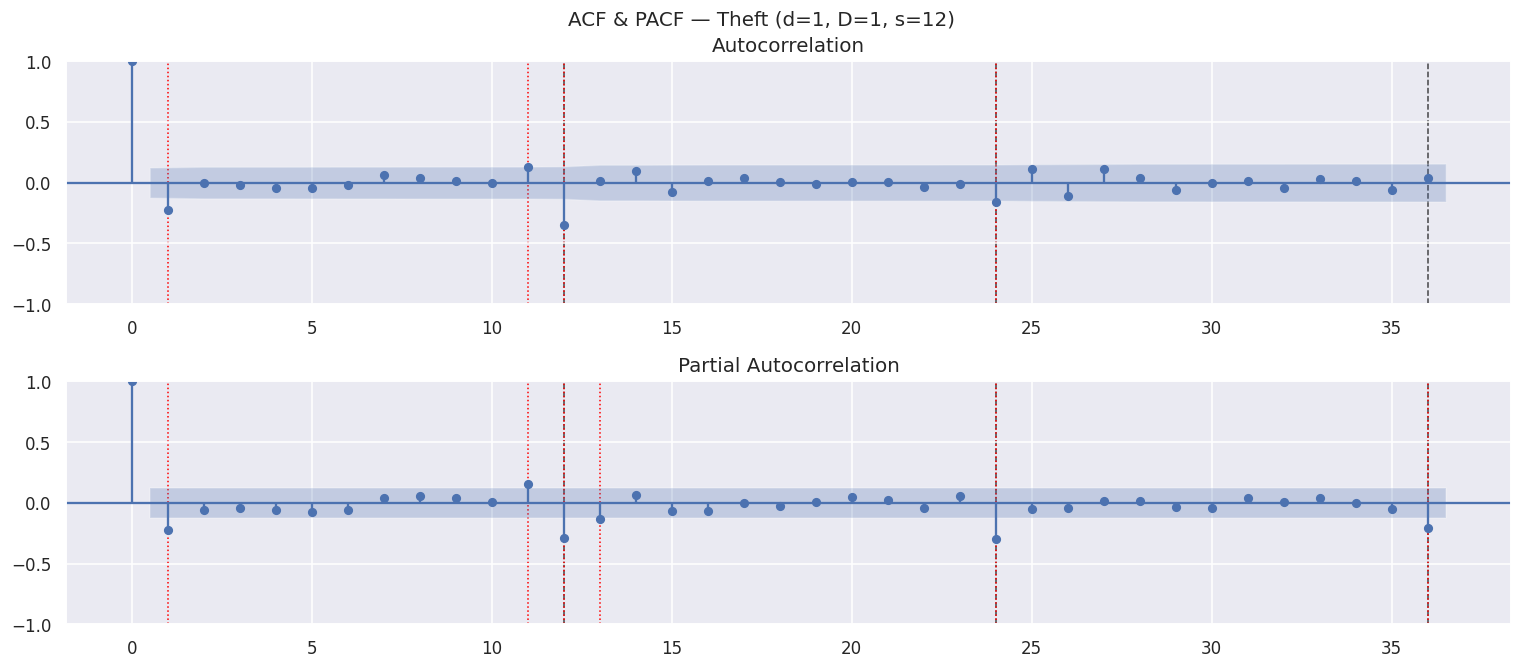

ACF:  significant spike at lag 1  -> MA(1) term
PACF: significant spike at lag 1  -> AR(1) term
Seasonal spikes at lag 12 in both -> P=1, Q=1

Selected manual order: SARIMA(1,1,1)(1,1,1,12)


In [19]:
diff_theft = theft_monthly.diff().diff(12).dropna()

fig = plot_acf_pacf(diff_theft, nlags=36, figsize=(14, 6),
                    annotate_sig=True, annotate_seas=True, m=12)
fig.suptitle("ACF & PACF — Theft (d=1, D=1, s=12)", y=1.01, fontsize=13)
plt.show()

print("ACF:  significant spike at lag 1  -> MA(1) term")
print("PACF: significant spike at lag 1  -> AR(1) term")
print("Seasonal spikes at lag 12 in both -> P=1, Q=1")
print("\nSelected manual order: SARIMA(1,1,1)(1,1,1,12)")


### B4 — Train / Test Split (6-month holdout)

In [20]:
train_theft = theft_monthly.iloc[:-6]
test_theft  = theft_monthly.iloc[-6:]

print(f"Train: {train_theft.index[0].date()} to {train_theft.index[-1].date()}  ({len(train_theft)} months)")
print(f"Test:  {test_theft.index[0].date()}  to {test_theft.index[-1].date()}   ({len(test_theft)} months)")
print(f"\nTest period (actual values):")
print(test_theft.to_string())


Train: 2001-01-01 to 2022-06-01  (258 months)
Test:  2022-07-01  to 2022-12-01   (6 months)

Test period (actual values):
Date
2022-07-01    5734
2022-08-01    5244
2022-09-01    5117
2022-10-01    5242
2022-11-01    4717
2022-12-01    4413
Freq: MS


### B5 — Manual SARIMA(1,1,1)(1,1,1,12)

In [21]:
model_theft_manual = SARIMAX(train_theft,
                              order=(1, 1, 1),
                              seasonal_order=(1, 1, 1, 12)).fit(disp=False)
print(model_theft_manual.summary())


                                     SARIMAX Results                                      
Dep. Variable:                        Crime_Count   No. Observations:                  258
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1768.542
Date:                            Mon, 20 Jul 2026   AIC                           3547.084
Time:                                    20:18:13   BIC                           3564.590
Sample:                                01-01-2001   HQIC                          3554.133
                                     - 06-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1943      0.228      0.853      0.394      -0.252       0.641
ma.L1         -0.4478      0.218   

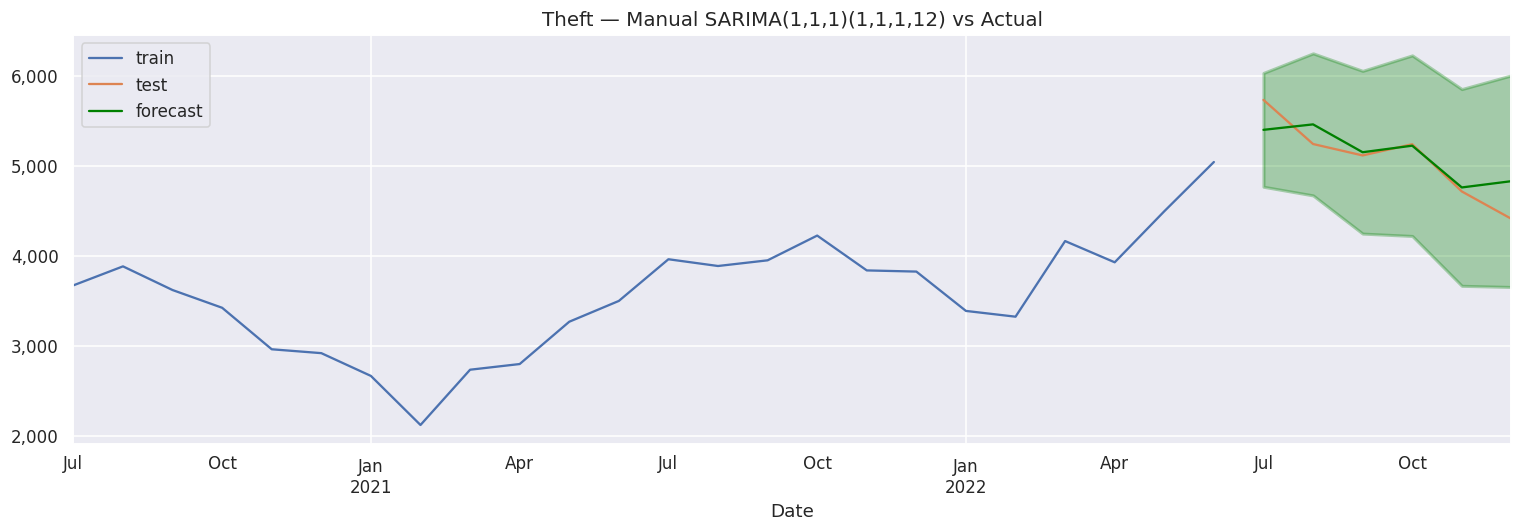

------------------------------------------------------------
Regression Metrics: Theft — Manual SARIMA(1,1,1)(1,1,1,12)
------------------------------------------------------------
- MAE  = 177.597
- MSE  = 56,098.929
- RMSE = 236.852
- R^2  = 0.682
- MAPE = 3.57%


In [22]:
result_theft_manual = model_theft_manual.get_forecast(6)
forecast_df_theft_manual = get_forecast_df(result_theft_manual)
forecast_df_theft_manual.index = test_theft.index

fig, ax = plot_forecast(train_theft, test_theft, forecast_df_theft_manual,
                        n_train_lags=24, figsize=(14, 5),
                        title="Theft — Manual SARIMA(1,1,1)(1,1,1,12) vs Actual")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
plt.tight_layout()
plt.show()

regression_metrics_ts(test_theft, forecast_df_theft_manual['mean'],
                      label='Theft — Manual SARIMA(1,1,1)(1,1,1,12)')


### B6 — auto_arima Tuning

In [23]:
aa_theft = pm.auto_arima(train_theft,
                          seasonal=True, m=12,
                          d=1, D=1,
                          stepwise=True,
                          suppress_warnings=True,
                          error_action='ignore',
                          trace=True)
print(f"\nBest order:    {aa_theft.order}")
print(f"Seasonal order: {aa_theft.seasonal_order}")


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=inf, Time=2.60 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=3625.667, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=3586.109, Time=0.24 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=3546.338, Time=0.63 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=3612.729, Time=0.06 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=3545.285, Time=0.99 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=3585.741, Time=0.26 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=3541.550, Time=2.04 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=3559.039, Time=0.62 sec
 ARIMA(0,1,1)(2,1,2)[12]             : AIC=3539.147, Time=7.60 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=3544.253, Time=2.20 sec
 ARIMA(0,1,0)(2,1,2)[12]             : AIC=3555.512, Time=1.89 sec
 ARIMA(1,1,1)(2,1,2)[12]             : AIC=3540.160, Time=7.61 sec
 ARIMA(0,1,2)(2,1,2)[12]             : AIC=3540.622, Time=4.90 sec
 ARIMA(1,1,0)(2,1,2)[12]

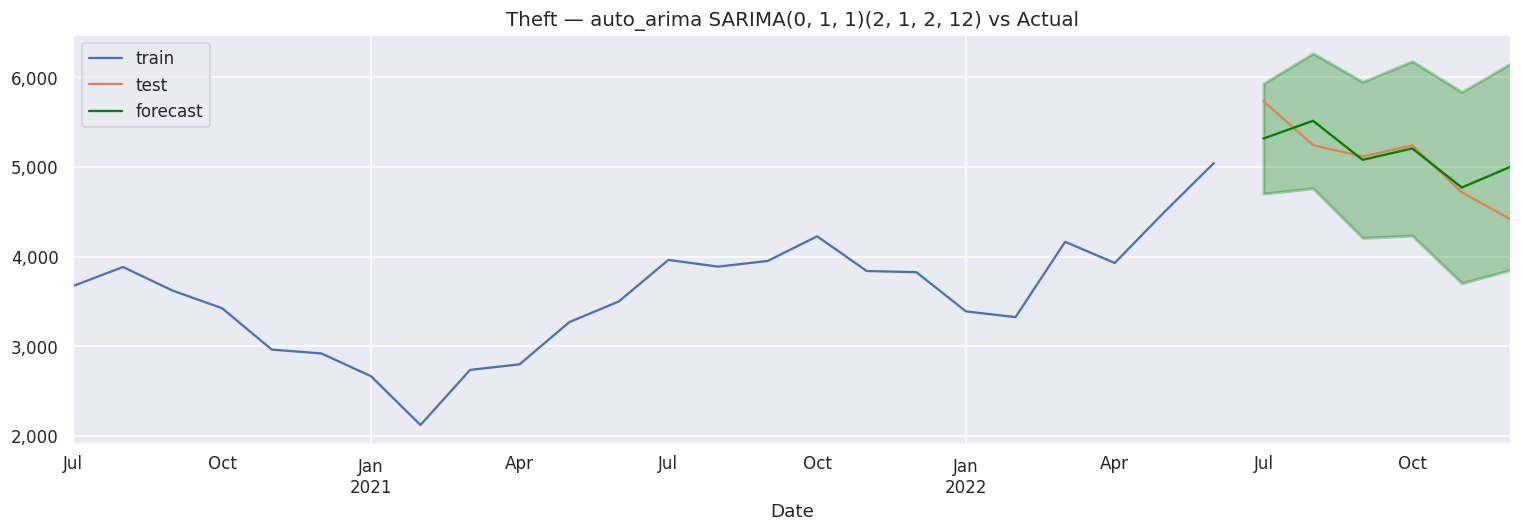

------------------------------------------------------------
Regression Metrics: Theft — auto_arima SARIMA(0, 1, 1)(2, 1, 2, 12)
------------------------------------------------------------
- MAE  = 234.538
- MSE  = 100,843.797
- RMSE = 317.559
- R^2  = 0.429
- MAPE = 4.74%


In [24]:
p, d, q = aa_theft.order
P, D, Q, m = aa_theft.seasonal_order

model_theft_auto = SARIMAX(train_theft,
                            order=(p, d, q),
                            seasonal_order=(P, D, Q, m)).fit(disp=False)

result_theft_auto = model_theft_auto.get_forecast(6)
forecast_df_theft_auto = get_forecast_df(result_theft_auto)
forecast_df_theft_auto.index = test_theft.index

fig, ax = plot_forecast(train_theft, test_theft, forecast_df_theft_auto,
                        n_train_lags=24, figsize=(14, 5),
                        title=f"Theft — auto_arima SARIMA{aa_theft.order}{aa_theft.seasonal_order} vs Actual")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
plt.tight_layout()
plt.show()

regression_metrics_ts(test_theft, forecast_df_theft_auto['mean'],
                      label=f'Theft — auto_arima SARIMA{aa_theft.order}{aa_theft.seasonal_order}')


### B7 — Model Selection

| Model | MAE | RMSE | MAPE |
|---|---|---|---|
| Manual SARIMA(1,1,1)(1,1,1,12) | 178 | 237 | 3.57% |
| auto_arima (0,1,1)(2,1,2,12) | 235 | 318 | 4.74% |

**Selected: Manual SARIMA(1,1,1)(1,1,1,12)**

The manual model achieves a strong MAPE of 3.57% vs 4.74% for auto_arima. The auto_arima selects a more complex seasonal structure (SMA(2) + SAR(2)) that overfits the training data and generalizes poorly on the 6-month holdout. The manual model is simpler and more accurate.


### B8 — True Future Forecast (Jan–Jun 2023)

Theft — True Future Forecast (Jan–Jun 2023):
2023-01-01    4024.0
2023-02-01    3670.0
2023-03-01    4237.0
2023-04-01    4109.0
2023-05-01    4658.0
2023-06-01    5035.0
Freq: MS


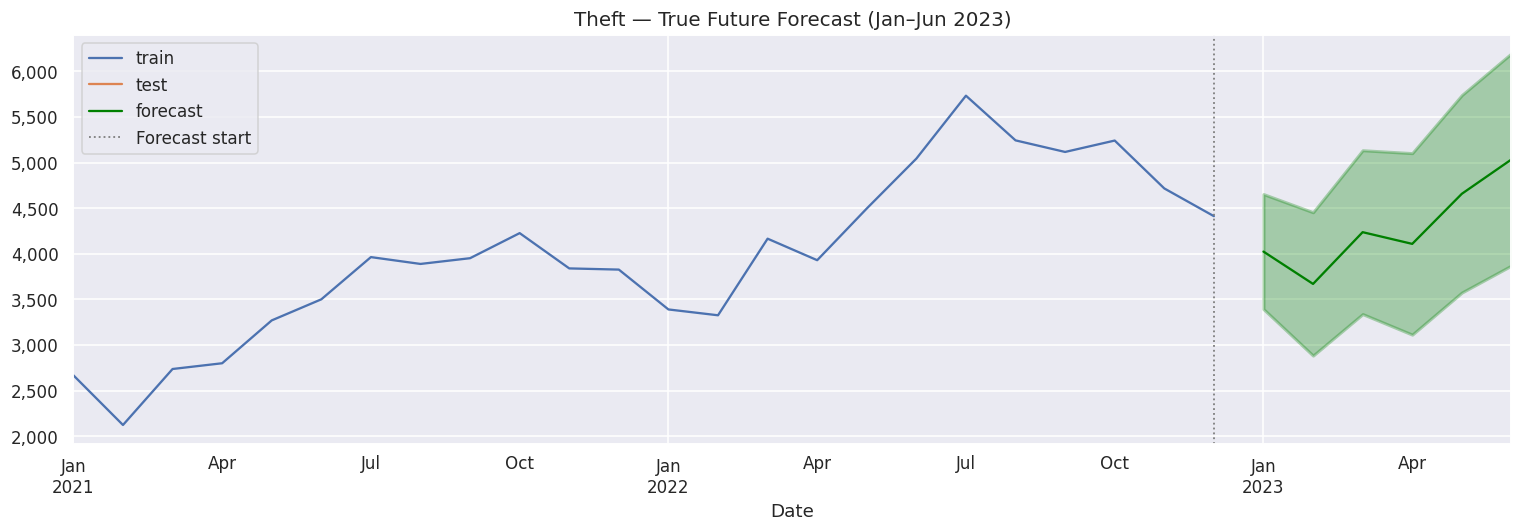

In [25]:
final_model_theft = SARIMAX(theft_monthly,
                             order=(1, 1, 1),
                             seasonal_order=(1, 1, 1, 12)).fit(disp=False)

result_future_theft = final_model_theft.get_forecast(6)
forecast_df_future_theft = get_forecast_df(result_future_theft)
forecast_df_future_theft.index = future_idx

print("Theft — True Future Forecast (Jan–Jun 2023):")
print(forecast_df_future_theft['mean'].round(0).to_string())

dummy_test_theft = pd.Series(dtype=float, index=future_idx, name='Crime_Count')

fig, ax = plot_forecast(theft_monthly, dummy_test_theft, forecast_df_future_theft,
                        n_train_lags=24, figsize=(14, 5),
                        title="Theft — True Future Forecast (Jan–Jun 2023)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
ax.axvline(theft_monthly.index[-1], color='gray', linestyle=':', linewidth=1.2, label='Forecast start')
ax.legend()
plt.tight_layout()
plt.show()


### B9 — Net Change & Percent Change

In [26]:
fc_theft = forecast_df_future_theft['mean']
delta_theft = fc_theft.iloc[-1] - fc_theft.iloc[0]
pct_theft   = delta_theft / fc_theft.iloc[0] * 100

print(f"Forecast start (Jan 2023): {fc_theft.iloc[0]:,.0f} thefts")
print(f"Forecast end   (Jun 2023): {fc_theft.iloc[-1]:,.0f} thefts")
print(f"Net change:     {delta_theft:+,.0f} thefts")
print(f"Percent change: {pct_theft:+.2f}%")


Forecast start (Jan 2023): 4,024 thefts
Forecast end   (Jun 2023): 5,035 thefts
Net change:     +1,010 thefts
Percent change: +25.10%


**Theft Forecast Analysis**

- **Net change:** +1,010 thefts from January to June 2023
- **Percent change:** +25.10%

Theft shows the steeper percent increase of the two crime types, driven by its strong seasonal summer pattern. The forecast rises sharply from a February trough to a June peak, consistent with the historical seasonality observed across all 22 years.


---
# Final Evaluation

| Question | Answer |
|---|---|
| Highest monthly count at end of forecast (Jun 2023) | **Total Crime** (22,893 vs 5,035) |
| Highest net change by end of forecast | **Total Crime** (+4,162 vs +1,010) |
| Highest percent change by end of forecast | **Theft** (+25.10% vs +22.22%) |

Both crime types follow the same seasonal trajectory: a winter trough in January/February followed by a strong climb to a June peak. Theft's higher percent change reflects a steeper seasonal swing relative to its lower baseline count.


### Reporting-Quality Comparison Visual

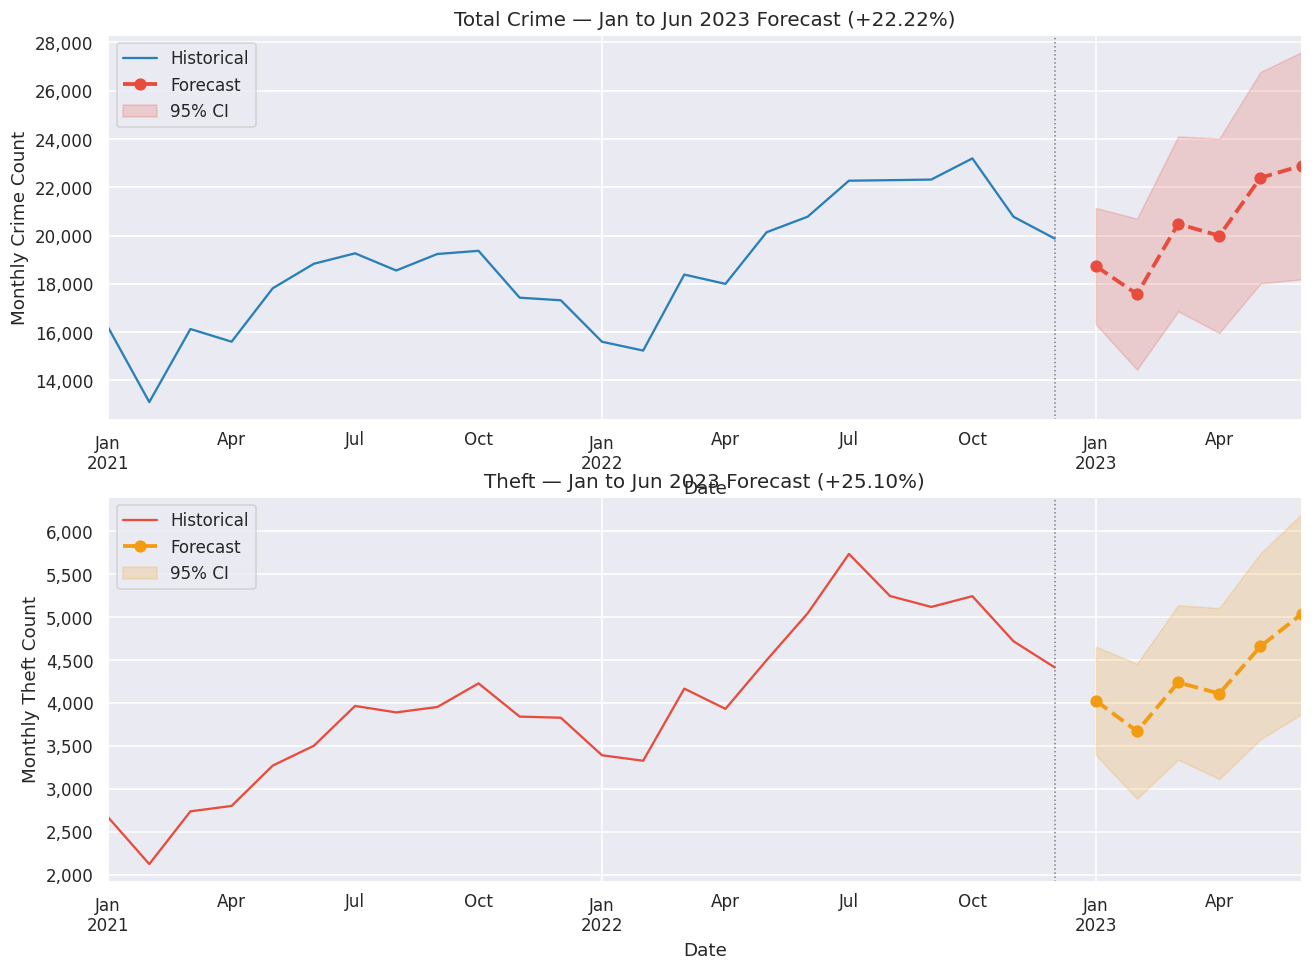

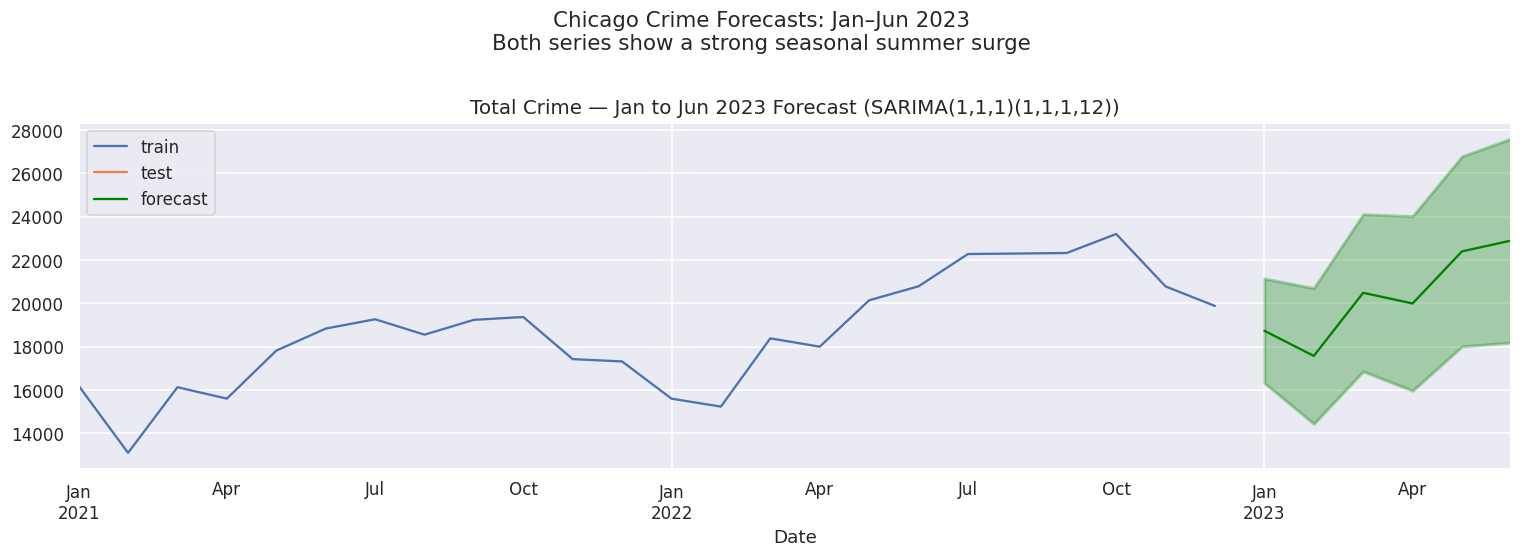

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# Total Crime
plot_forecast(total_monthly, dummy_test, forecast_df_future_total,
              n_train_lags=24, figsize=(14, 5),
              title="Total Crime — Jan to Jun 2023 Forecast (SARIMA(1,1,1)(1,1,1,12))")
# Replot properly on shared figure
axes[0].clear()
total_monthly.iloc[-24:].plot(ax=axes[0], label='Historical', color='#2980b9', linewidth=1.5)
forecast_df_future_total['mean'].plot(ax=axes[0], color='#e74c3c', linestyle='--',
                                       linewidth=2.5, marker='o', markersize=7, label='Forecast')
axes[0].fill_between(forecast_df_future_total.index,
                     forecast_df_future_total['mean_ci_lower'],
                     forecast_df_future_total['mean_ci_upper'],
                     color='#e74c3c', alpha=0.2, label='95% CI')
axes[0].axvline(total_monthly.index[-1], color='gray', linestyle=':', linewidth=1)
axes[0].set_title("Total Crime — Jan to Jun 2023 Forecast (+22.22%)", fontsize=13)
axes[0].set_ylabel("Monthly Crime Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
axes[0].legend()

# Theft
axes[1].clear()
theft_monthly.iloc[-24:].plot(ax=axes[1], label='Historical', color='#e74c3c', linewidth=1.5)
forecast_df_future_theft['mean'].plot(ax=axes[1], color='#f39c12', linestyle='--',
                                       linewidth=2.5, marker='o', markersize=7, label='Forecast')
axes[1].fill_between(forecast_df_future_theft.index,
                     forecast_df_future_theft['mean_ci_lower'],
                     forecast_df_future_theft['mean_ci_upper'],
                     color='#f39c12', alpha=0.2, label='95% CI')
axes[1].axvline(theft_monthly.index[-1], color='gray', linestyle=':', linewidth=1)
axes[1].set_title("Theft — Jan to Jun 2023 Forecast (+25.10%)", fontsize=13)
axes[1].set_ylabel("Monthly Theft Count")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
axes[1].legend()

plt.suptitle("Chicago Crime Forecasts: Jan–Jun 2023\nBoth series show a strong seasonal summer surge",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


---
# Final Recommendations

## Resource Allocation Recommendations for Chicago Law Enforcement

| Metric | Total Crime | Theft |
|---|---|---|
| Jan 2023 (forecast start) | 18,731 | 4,024 |
| Jun 2023 (forecast end) | 22,893 | 5,035 |
| Net change | +4,162 | +1,010 |
| Percent change | +22.22% | +25.10% |
| Selected model | SARIMA(1,1,1)(1,1,1,12) | SARIMA(1,1,1)(1,1,1,12) |
| Test MAPE | 6.89% | 3.57% |

### Recommendations

1. **Scale up patrol resources from April onward.** Both Total Crime and Theft begin their seasonal climb in March/April. Pre-positioning officers before the peak is more effective and cost-efficient than reactive reallocation in June.

2. **Prioritize Theft prevention in May and June.** Theft shows the steeper percent increase (+25.10%) and is historically the most common crime type in Chicago. Targeted anti-theft patrols in high-density commercial areas and District 8 (highest 2022 count) are strongly recommended.

3. **Reduce patrol intensity in January and February.** Both forecasts show a clear winter trough. Resources freed during these months can be redirected to officer training, community outreach, or administrative operations without sacrificing coverage.

4. **Monitor Motor Vehicle Theft separately.** As identified in Part 1, MVT showed a sharp post-2020 surge, a winter-leaning seasonal pattern, and a PM Rush peak — all counter to the overall trends. It warrants its own dedicated SARIMA forecast and resource plan.
